# 01: Exploratory Data Analysis: cc_general.csv

This notebook explores the cc_general.csv credit-card customer dataset to motivate
the preprocessing choices made in `src/data.py` and to select a reasonable
range of k for the clustering experiments.

**Dataset**: 8,950 customers × 17 numeric features (balances, purchases,
cash advances, repayment behavior, credit limits, tenure).

In [1]:
import sys
import os

# Make src/ importable from the notebooks/ directory
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.ticker

matplotlib.rcParams['figure.dpi'] = 120
plt.style.use('seaborn-v0_8-whitegrid')

FIGURES_DIR = '../report/figures'
DATA_PATH   = '../data/cc_general.csv'
SEED        = 42

os.makedirs(FIGURES_DIR, exist_ok=True)

## 1. Load and inspect the raw data

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.0,0.083333,0.00,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.0,0.000000,0.25,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.0,0.000000,0.00,0,12,7500.0,622.066742,627.284787,0.000000,12


In [3]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.47,2081.53,0.00,128.28,873.39,2054.14,19043.14
BALANCE_FREQUENCY,8950.0,0.88,0.24,0.00,0.89,1.00,1.00,1.00
PURCHASES,8950.0,1003.20,2136.63,0.00,39.64,361.28,1110.13,49039.57
ONEOFF_PURCHASES,8950.0,592.44,1659.89,0.00,0.00,38.00,577.40,40761.25
INSTALLMENTS_PURCHASES,8950.0,411.07,904.34,0.00,0.00,89.00,468.64,22500.00
CASH_ADVANCE,8950.0,978.87,2097.16,0.00,0.00,0.00,1113.82,47137.21
PURCHASES_FREQUENCY,8950.0,0.49,0.40,0.00,0.08,0.50,0.92,1.00
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.20,0.30,0.00,0.00,0.08,0.30,1.00
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.36,0.40,0.00,0.00,0.17,0.75,1.00
CASH_ADVANCE_FREQUENCY,8950.0,0.14,0.20,0.00,0.00,0.00,0.22,1.50


## 2. Missing values

Only two columns have missing values.  
`MINIMUM_PAYMENTS` (~3.5%) and `CREDIT_LIMIT` (1 row).  
Median imputation is used because these financial variables are strongly right-skewed.

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
summary[summary['missing_count'] > 0]

,missing_count,missing_pct
CREDIT_LIMIT,1,0.01
MINIMUM_PAYMENTS,313,3.50


## 3. Feature distributions

Most financial variables are strongly right-skewed.
Standardization is therefore necessary before any distance-based algorithm.

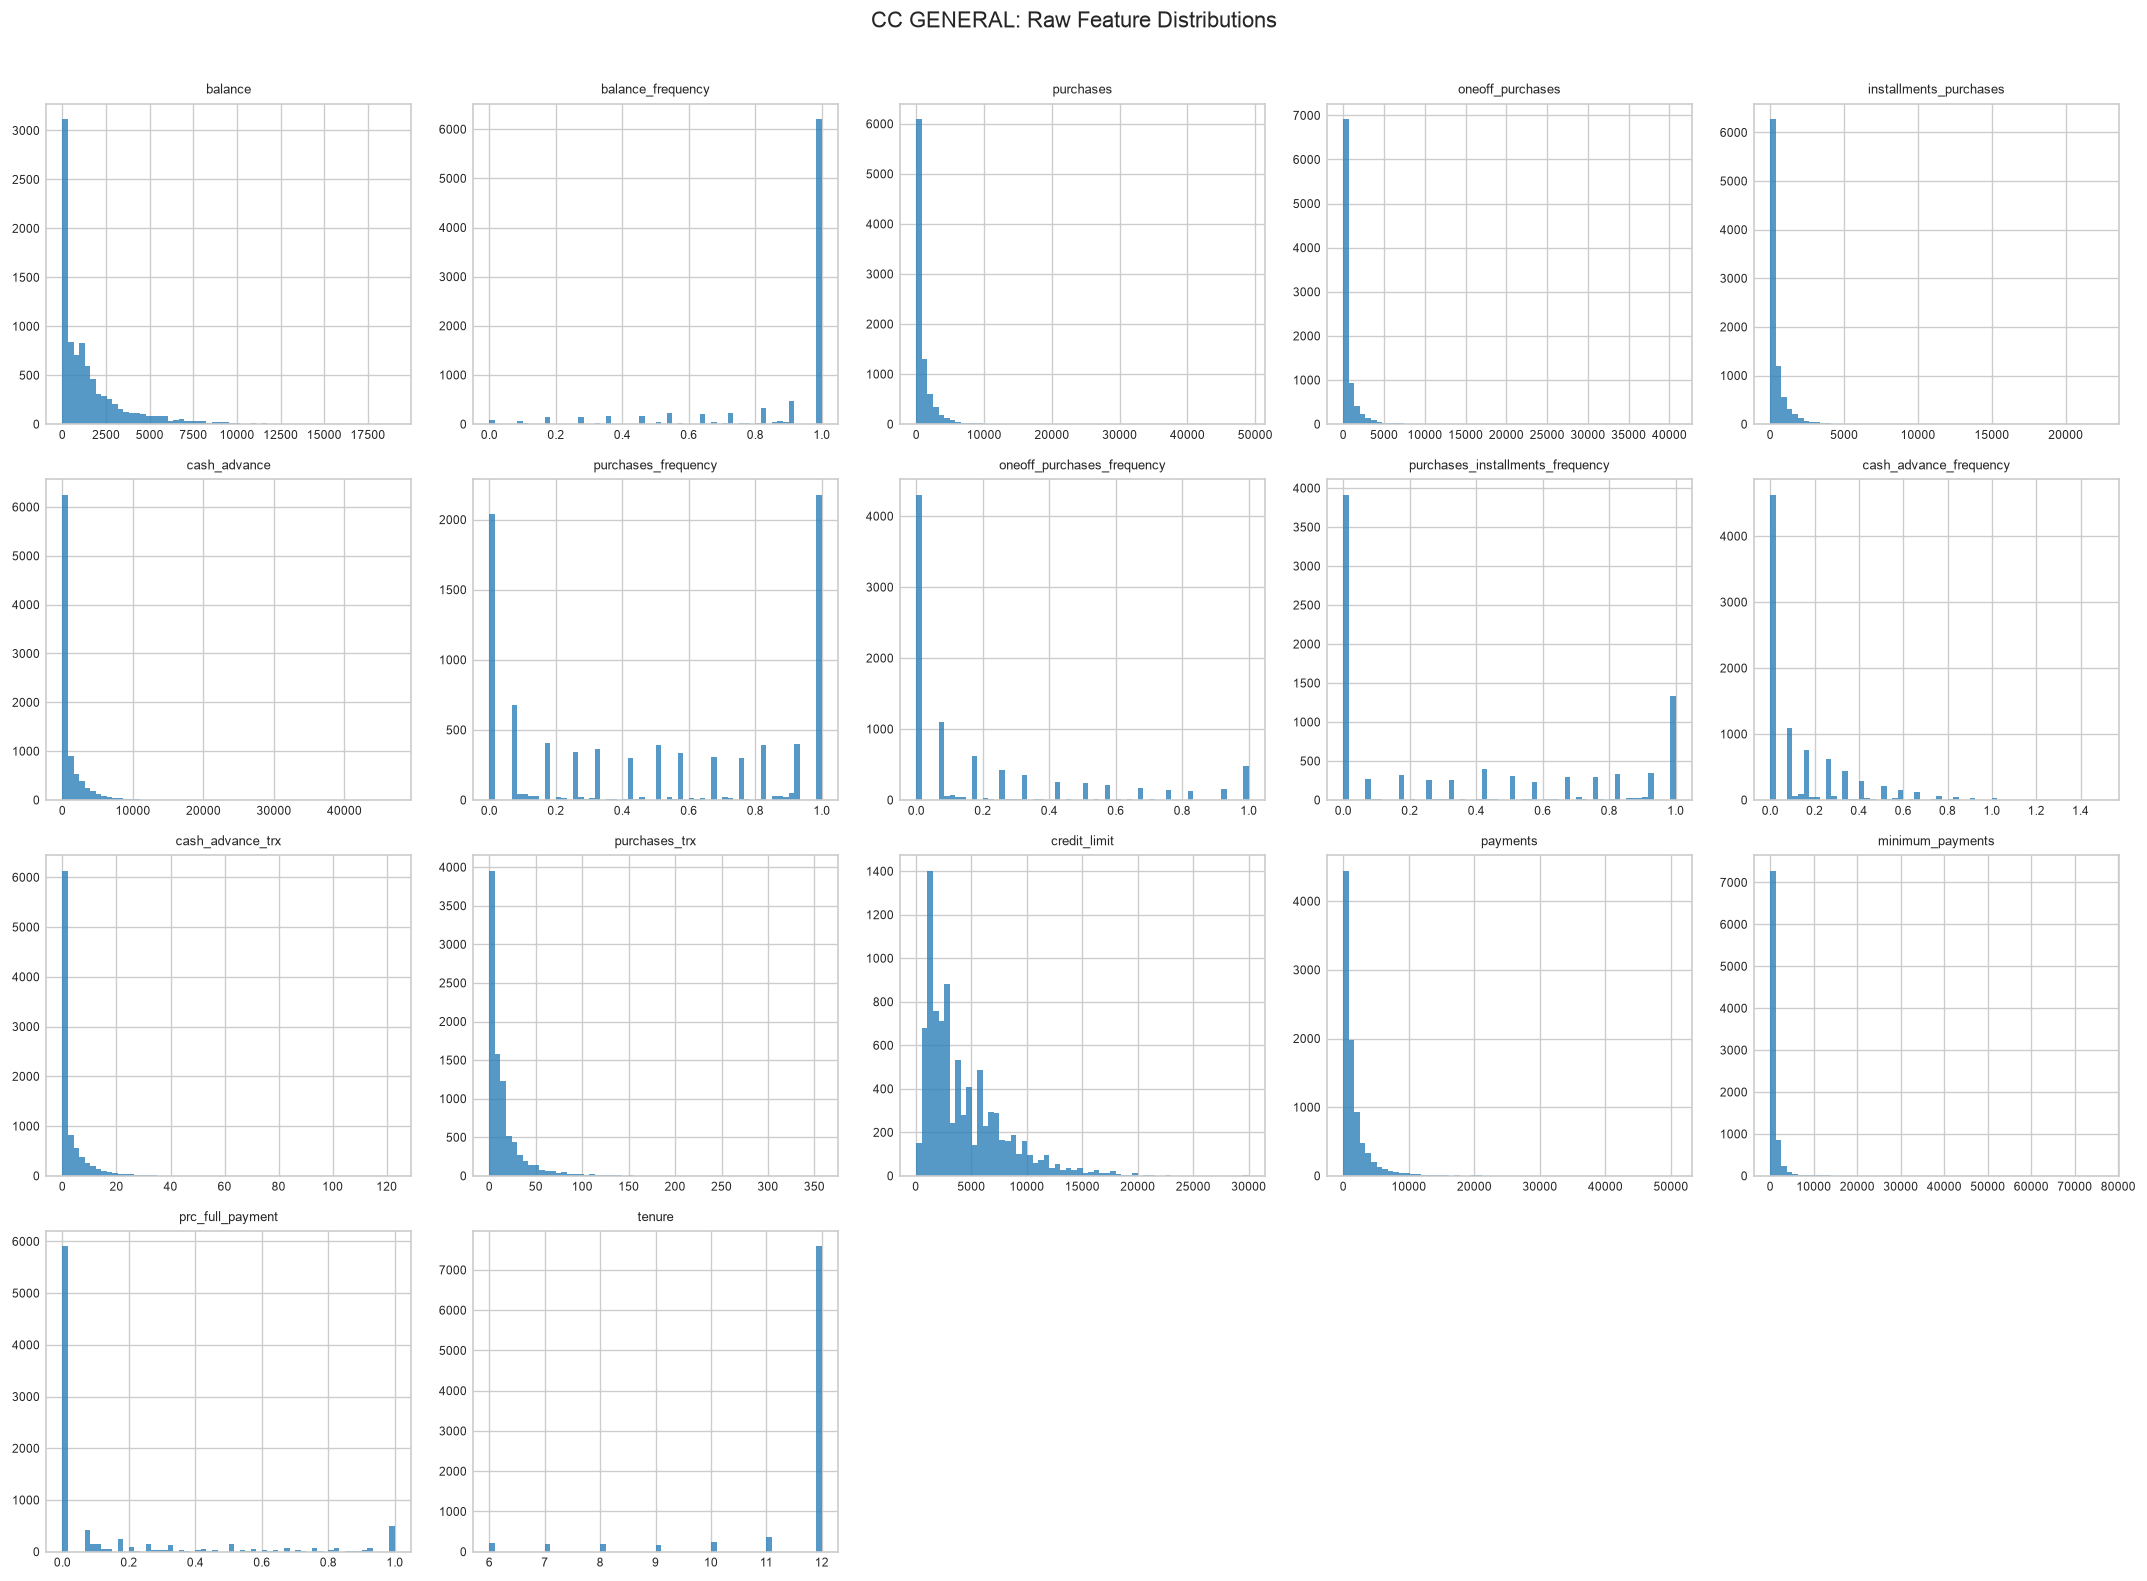

In [5]:
feature_cols = [c for c in df.columns if c != 'CUST_ID']
n_cols = len(feature_cols)  # 17

fig, axes = plt.subplots(4, 5, figsize=(18, 13))
for ax, col in zip(axes.flat, feature_cols):
    ax.hist(df[col].dropna(), bins=60, color='#2C7FB8', alpha=0.8, edgecolor='none')
    ax.set_title(col.lower(), fontsize=8)
    ax.tick_params(labelsize=7)

# Hide the two unused subplots (4x5 = 20 > 17)
for ax in axes.flat[n_cols:]:
    ax.set_visible(False)

plt.suptitle('CC GENERAL: Raw Feature Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Key scatter plots

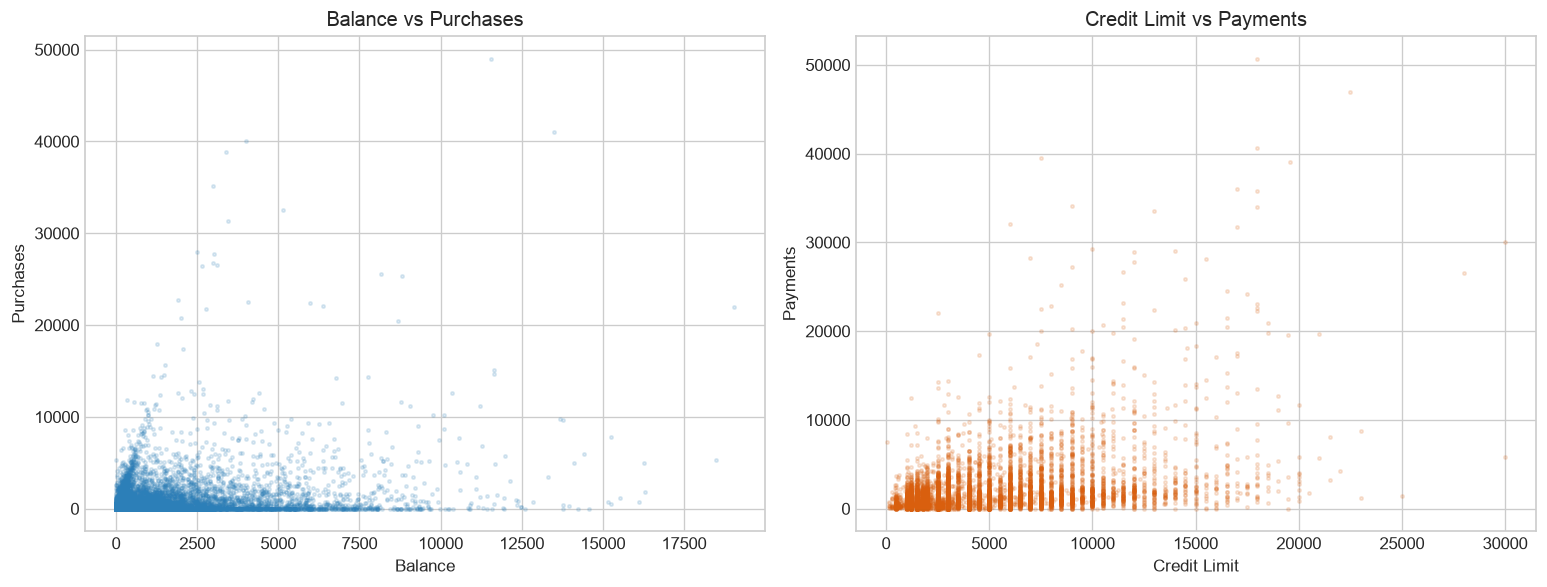

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.scatter(df['BALANCE'], df['PURCHASES'], alpha=0.15, s=4, color='#2C7FB8')
ax1.set_xlabel('Balance'); ax1.set_ylabel('Purchases')
ax1.set_title('Balance vs Purchases')

ax2.scatter(df['CREDIT_LIMIT'], df['PAYMENTS'], alpha=0.15, s=4, color='#D95F0E')
ax2.set_xlabel('Credit Limit'); ax2.set_ylabel('Payments')
ax2.set_title('Credit Limit vs Payments')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/eda_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Correlation structure

Purchase-related variables cluster together; cash-advance variables form a
separate block. This overlap motivates dimensionality assessment via PCA.

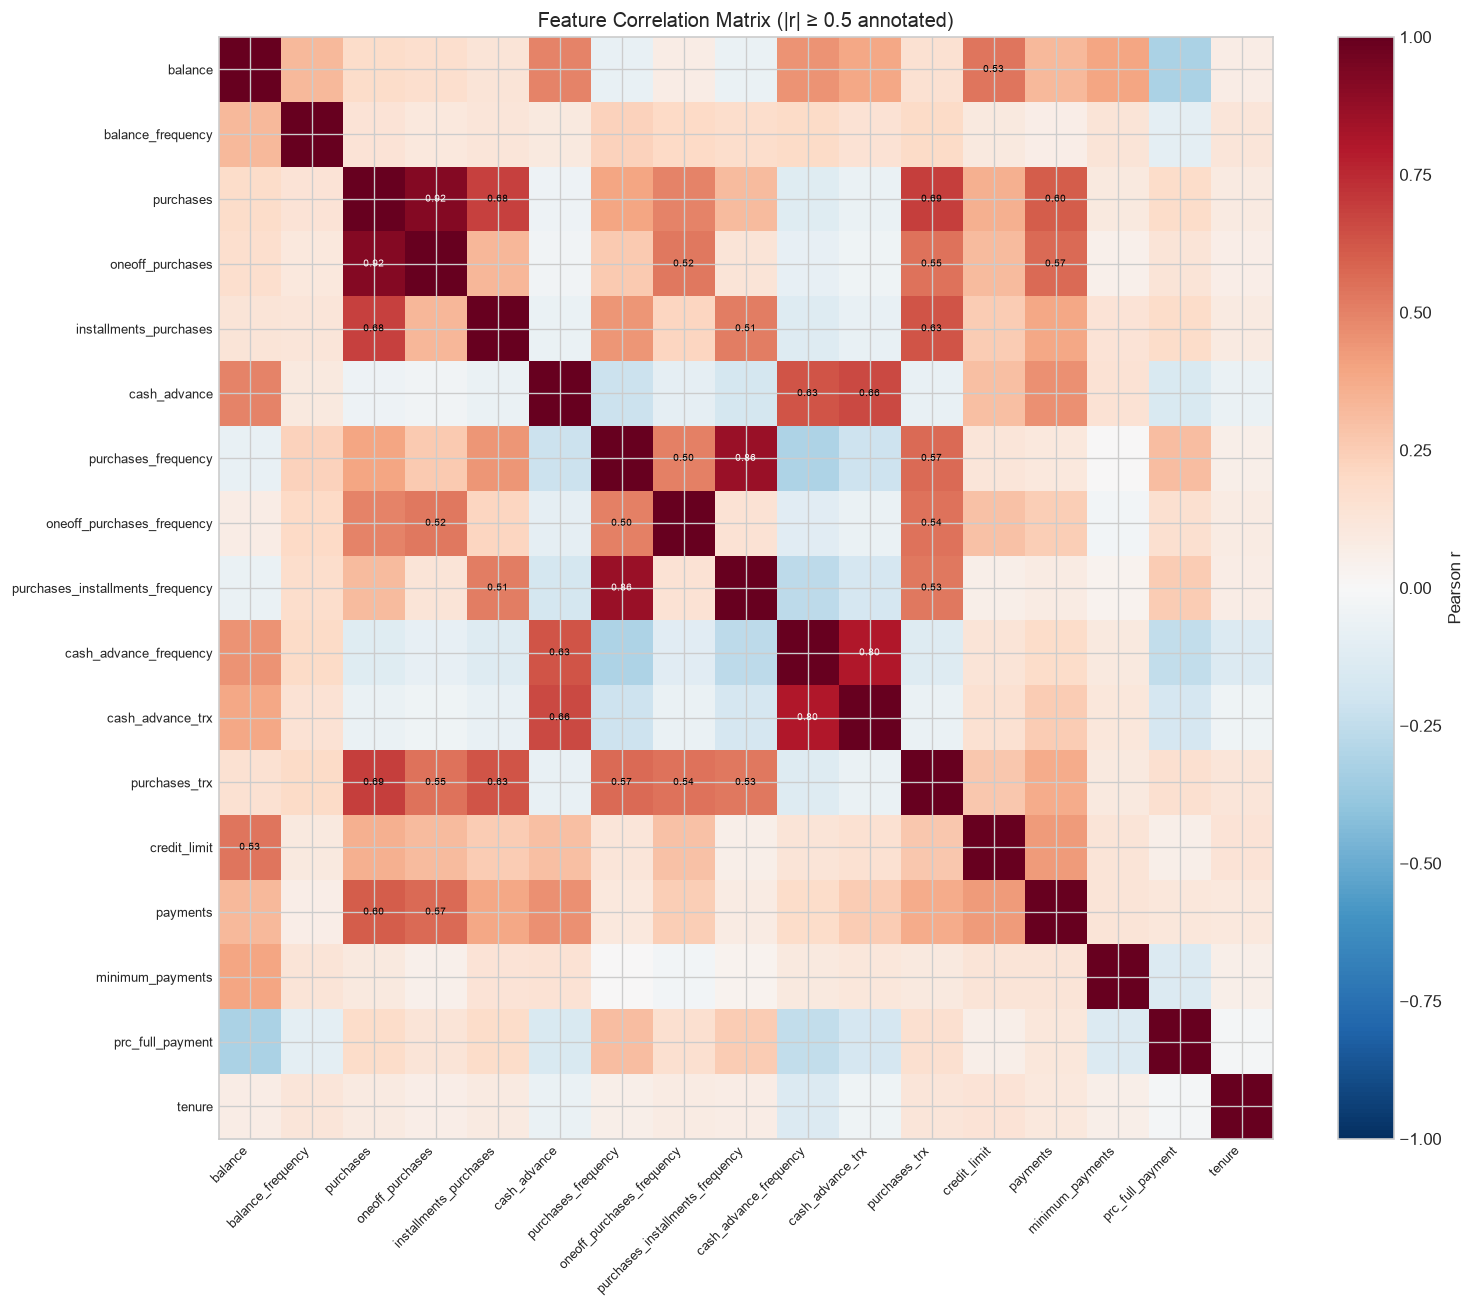

In [7]:
numeric_df = df[feature_cols].fillna(df[feature_cols].median())
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels([c.lower() for c in corr.columns], rotation=45, ha='right', fontsize=8)
ax.set_yticklabels([c.lower() for c in corr.columns], fontsize=8)
plt.colorbar(im, ax=ax, label='Pearson r')

# Annotate cells with |r| >= 0.5
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.values[i, j]
        if abs(v) >= 0.5 and i != j:
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=6,
                    color='white' if abs(v) > 0.7 else 'black')

ax.set_title('Feature Correlation Matrix (|r| ≥ 0.5 annotated)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. PCA: How many components explain 80% of variance?

Using the standardized matrix from `src/data.load_cc_general`.

Standardized data shape: (8950, 17)
Components needed for 80% variance: 7


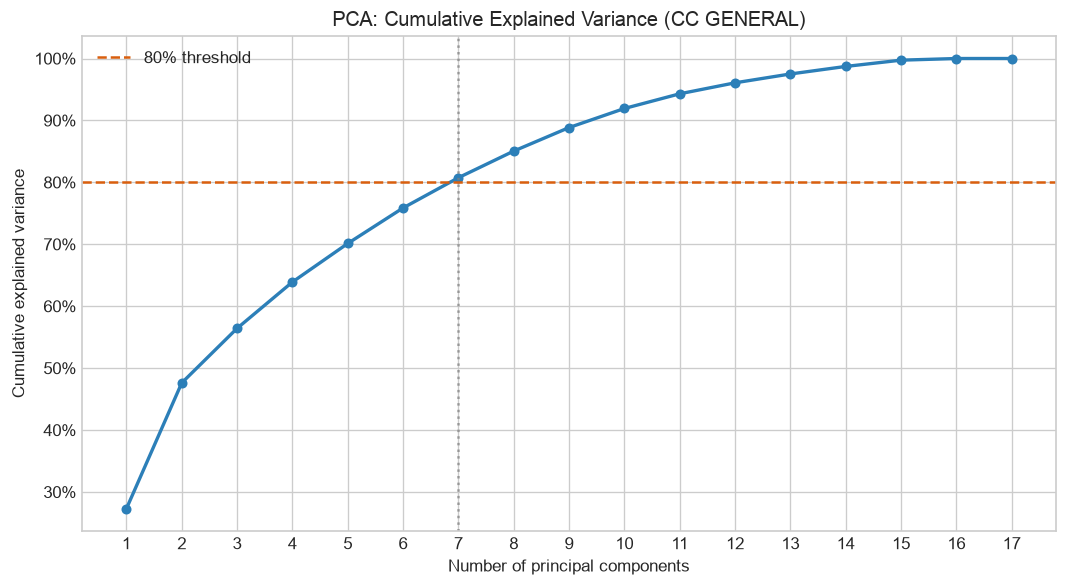

In [8]:
from src.data import load_cc_general

X = load_cc_general(DATA_PATH)
print(f'Standardized data shape: {X.shape}')

# SVD-based PCA (no sklearn needed for this step)
_, sv, _ = np.linalg.svd(X, full_matrices=False)
explained_var = sv**2 / (sv**2).sum()
cumulative_var = np.cumsum(explained_var)

n_80 = int(np.searchsorted(cumulative_var, 0.80)) + 1
print(f'Components needed for 80% variance: {n_80}')

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(cumulative_var) + 1), cumulative_var, 'o-',
        color='#2C7FB8', linewidth=2, markersize=5)
ax.axhline(0.80, linestyle='--', color='#D95F0E', label='80% threshold')
ax.axvline(n_80, linestyle=':', color='gray', alpha=0.7)
ax.set_xlabel('Number of principal components')
ax.set_ylabel('Cumulative explained variance')
ax.set_title('PCA: Cumulative Explained Variance (CC GENERAL)')
ax.set_xticks(range(1, len(cumulative_var) + 1))
ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1))
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/eda_pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Elbow plot: choosing a candidate range of k

Uses k-means++ with 5 restarts as a fast probe.  
The elbow guides which k values to focus on in the main experiments.

k=2  inertia=127784.3
k=3  inertia=111973.4
k=4  inertia=99061.9
k=5  inertia=91491.1
k=6  inertia=84825.0
k=7  inertia=80088.4
k=8  inertia=74597.8
k=9  inertia=70894.7
k=10  inertia=68352.4


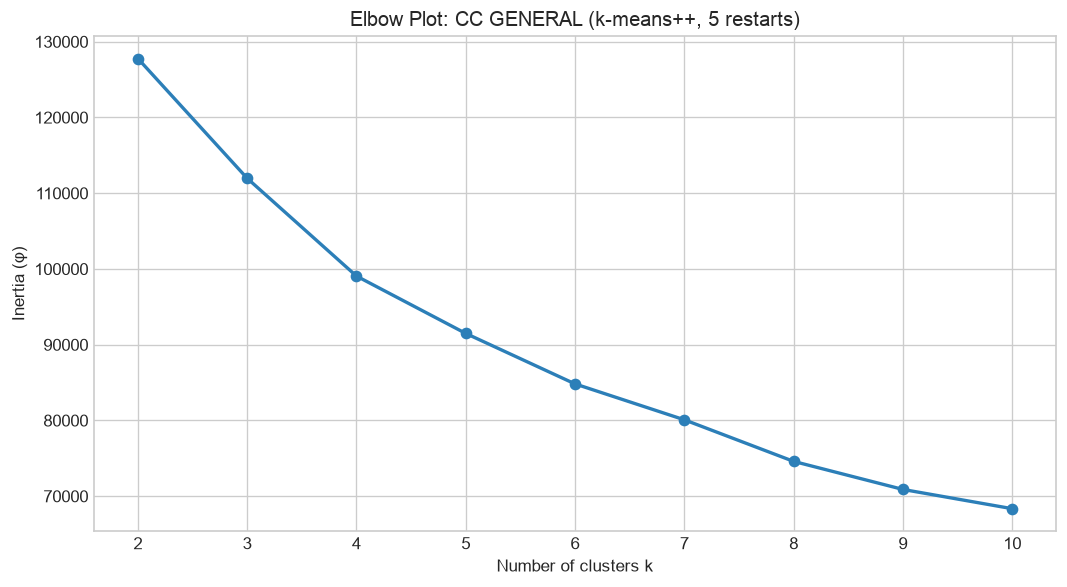

In [9]:
from src.kmeans import KMeans

k_range = range(2, 11)
inertias = []

for k in k_range:
    model = KMeans(k=k, init='plusplus', n_init=5, random_state=SEED)
    model.fit(X)
    inertias.append(model.inertia_)
    print(f'k={k}  inertia={model.inertia_:.1f}')

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(k_range), inertias, 'o-', color='#2C7FB8', linewidth=2, markersize=6)
ax.set_xlabel('Number of clusters k')
ax.set_ylabel('Inertia (φ)')
ax.set_title('Elbow Plot: CC GENERAL (k-means++, 5 restarts)')
ax.set_xticks(list(k_range))
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/eda_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Summary

| Finding | Implication |
|---|---|
| Right-skewed financial variables | Standardization is essential before distance-based clustering |
| MINIMUM_PAYMENTS 3.5% missing | Median imputation is appropriate |
| Purchase and cash-advance correlation blocks | Some structural overlap; PCA would compact these |
| ~7 PCA components reach 80% variance | 17 features carry redundancy |
| Elbow visible at k=3 or k=4 | Focus experiments on k=2-8 |

Proceed to `02_synthetic_experiments.ipynb` for controlled initialization comparison.